In [27]:
"""

Main objetive is to gathering the audio files from the lesson recordings and transcribe them to text, then clean the text by removing accents and stopwords, and finally visualize the most common words in a bar plot.
After that, we will send the text to ChatGPT to summarize the text and generate a study guide for the lesson.

"""
import whisper
import os
import unicodedata
from nltk.corpus import stopwords
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import re
import numpy as np
import math


In [2]:
"""load the model from OpenAI to make the transcription of the audio file"""
model = whisper.load_model("tiny")

In [3]:
def gathering_audio_files(dir_path):
    """
    Gather all audio files from the specified folder and return a list of their paths.
    """
    complete_text = []
    num_files = len(os.listdir(dir_path))
    for file in range(num_files):
         file= os.listdir(dir_path)[file]
         file_dir = os.path.join(dir_path, file)
         result = model.transcribe(file_dir)
         concatenated_text = result["text"]
         complete_text.append(concatenated_text)
         #print(f"File {file+1}/{num_files} processed: {file} characters: {len(concatenated_text)}")
    complete_text_str = "".join(complete_text)
    return complete_text_str          

In [7]:
def cleaning_data(text):
    """
    Clean the text by removing accents, stopwords, and special characters.
    """
    # Convert to lowercase
    text = text.lower()

    # Remove accents
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')

    # Remove special characters and digits
    text = re.sub(r'[;:,\.\-\"‘/()\[\]¿\?¡!{}~<>|«»—’]', '', text)
    
    # Remove stopwords
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))
    words = text.split()
    cleaned_text = ' '.join(word for word in words if word not in stop_words)
    
    return cleaned_text

In [8]:
cleaned_text = cleaning_data(complete_text_v1)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodrigo.romero\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
base_path = "C:/Users/rodrigo.romero/Documents/personal_projects/whisper_project/lesson_recordings"
#folders = os.listdir(base_path)
folders = ['lesson_recordings (1)', 'lesson_recordings (2)','lesson_recordings (3)','lesson_recordings (4)','lesson_recordings (5)']
data = {}
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        complete_text = gathering_audio_files(folder_path)
        cleaned_text = cleaning_data(complete_text)
        data[folder] = cleaned_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodrigo.romero\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodrigo.romero\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodrigo.romero\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodrigo.romero\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodrigo.romero\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
data['lesson_recordings (1)']

"know know really nice meet one moment okay can't speaking okay dealing something real quick one man think gonna try something little bit basic today hard actually happened past couple lessons mind asking sorry missing schedule even another city sorry game sound different obtain class got raise okay worries would really appreciate next time could let know let text know handle situation okay yeah right works gonna share screen right one moment okay let know uh different workbook one sent okay think start first hold okay like ask first look speaking framework opinion reason opinion example result need one focus first okay okay right kind travel experiences enjoy think topic frame often joined related one thing maybe opportunity see nature think related nature example couple weeks ago visited applies called can't count mexico city beautiful beach mexico okay okay yeah result impact well result kind experiences think feel comfortable enjoy seaside nature views alone okay right checking um 

In [65]:
# Barbplot 
words=data['lesson_recordings (1)'].split() # con la función split obtenemos las palabras que contiene el texto
bigrams = [(words[i], words[i+1]) for i in range(len(words)-1)]
bigram_counts = Counter(bigrams)
frecuencias_bigrams_ordenado = dict(sorted(bigram_counts.items(), key=lambda item: item[1],reverse=True))
frecuencias_bigrams_ordenado = dict(list(frecuencias_bigrams_ordenado.items())[0:10])
frecuencias_bigrams_ordenado





{('okay', 'okay'): 39,
 ('okay', 'right'): 13,
 ('little', 'bit'): 11,
 ('let', 'know'): 5,
 ('part', 'two'): 5,
 ('new', 'perspectives'): 5,
 ('travel', 'important'): 5,
 ('important', 'personal'): 5,
 ('personal', 'growth'): 5,
 ('speaking', 'framework'): 4}

In [71]:
frecuencias_bigrams_ordenado.keys()

dict_keys([('okay', 'okay'), ('okay', 'right'), ('little', 'bit'), ('let', 'know'), ('part', 'two'), ('new', 'perspectives'), ('travel', 'important'), ('important', 'personal'), ('personal', 'growth'), ('speaking', 'framework')])

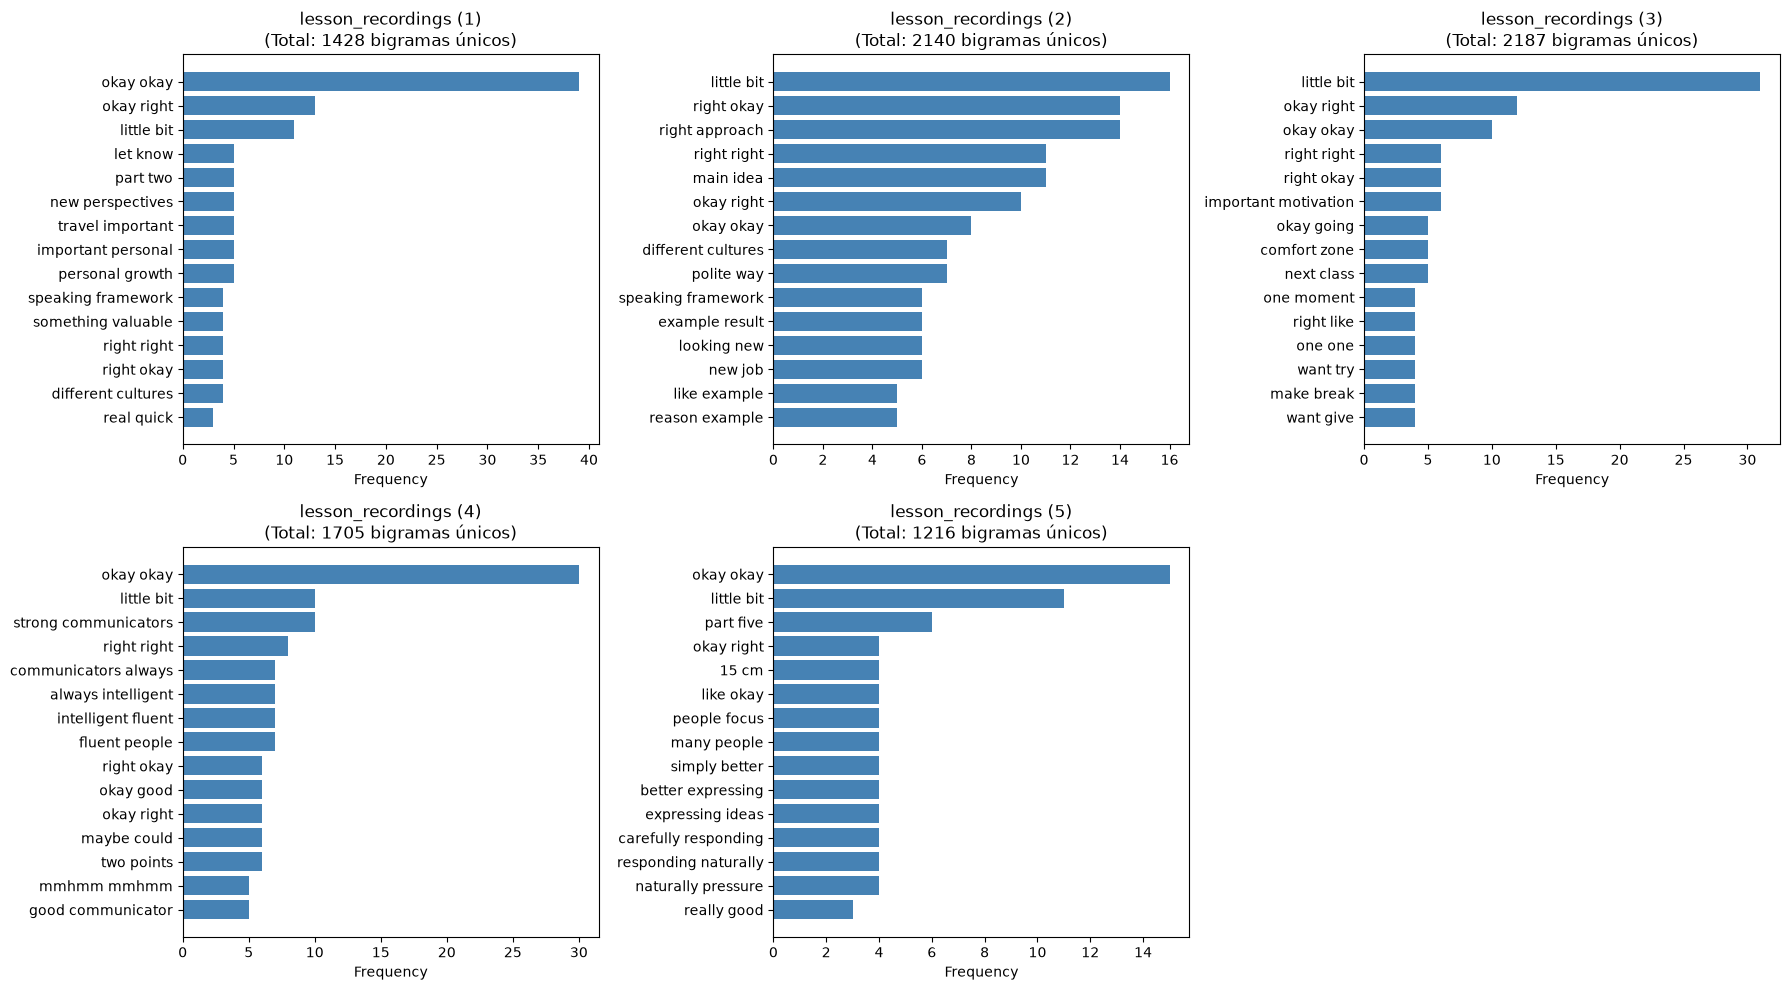

In [72]:
# Bigram frequency visualization - TOP 15 per lesson
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, folder in enumerate(folders):
    words_list = data[folder].split()
    bigrams = [(words_list[i] + ' ' + words_list[i+1]) for i in range(len(words_list)-1)]
    bigram_freq = Counter(bigrams)
    
    # Get top 15 bigramas
    top_15_bigrams = dict(sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)[:15])
    
    axes[idx].barh(list(top_15_bigrams.keys()), list(top_15_bigrams.values()), color='steelblue')
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_title(f'{folder}\n(Total: {len(bigram_freq)} bigramas únicos)')
    axes[idx].invert_yaxis()

# Remove empty subplot
axes[5].remove()

plt.tight_layout()
plt.show()

In [ ]:
# Barbplot 
bigrams=data['lesson_recordings (1)'].split() # con la función split obtenemos las palabras que contiene el texto
frecuencias_bigrams=Counter(bigrams) 
frecuencias_bigrams_ordenado = dict(sorted(frecuencias_bigrams.items(), key=lambda item: item[1],reverse=True))
frecuencias_bigrams_ordenado = dict(list(frecuencias_bigrams_ordenado.items())[0:10])
frecuencias_bigrams_ordenado

In [ ]:

def calculate_word_entropy(text):
    """
    Calculate the entropy of the given text.
    """
    words_list = text.split()
    word_counts = Counter(words_list)
    total_words = sum(word_counts.values())
    
    H = 0
    for n in word_counts.values():
        p = n / total_words
        H += -p * math.log2(p)
    
    return "Entropia:" + str(H) + " bits/caracter"

In [40]:
print(calculate_word_entropy(data['lesson_recordings (1)']))
print(calculate_word_entropy(data['lesson_recordings (2)']))
print(calculate_word_entropy(data['lesson_recordings (3)']))
print(calculate_word_entropy(data['lesson_recordings (4)']))
print(calculate_word_entropy(data['lesson_recordings (5)']))

Entropia:8.149006374823246bits/caracter
Entropia:8.458981443292954bits/caracter
Entropia:8.502758482584575bits/caracter
Entropia:8.292358589289364bits/caracter
Entropia:8.297849410464154bits/caracter


In [41]:
def calculate_bigram_entropy(text):
    """
    Calculate the entropy of bigrams (consecutive word pairs) in the given text.
    """
    words_list = text.split()
    bigrams = [(words_list[i], words_list[i+1]) for i in range(len(words_list)-1)]
    bigram_counts = Counter(bigrams)
    total_bigrams = sum(bigram_counts.values())
    
    H = 0
    for count in bigram_counts.values():
        p = count / total_bigrams
        H += -p * math.log2(p)
    
    return H


In [42]:
print(calculate_bigram_entropy(data['lesson_recordings (1)']))
print(calculate_bigram_entropy(data['lesson_recordings (2)']))
print(calculate_bigram_entropy(data['lesson_recordings (3)']))
print(calculate_bigram_entropy(data['lesson_recordings (4)']))
print(calculate_bigram_entropy(data['lesson_recordings (5)']))

10.29166144479284
10.880455579374475
10.959416218850787
10.532275076046702
10.102278000194326


In [43]:
#words_probabilities
sum_p = sum(frecuencias_palabras.values())
probabilidades_palabras={}
for i in frecuencias_palabras:
    probabilidades_palabras[i] = float(frecuencias_palabras[i]/sum_p)
list(probabilidades_palabras.items())[:10]

[('hi', 0.00038580246913580245),
 ('romero', 0.0019290123456790122),
 ('nice', 0.0007716049382716049),
 ('see', 0.0073302469135802465),
 ('today', 0.0019290123456790122),
 ('fine', 0.0011574074074074073),
 ('also', 0.004629629629629629),
 ('okay', 0.03973765432098766),
 ('think', 0.015817901234567902),
 ('like', 0.015432098765432098)]

In [44]:
#joint_probabilities_words
pares = [(words[i], words[i+1]) for i in range(len(words)-1)]
frecuencias_pares = Counter(pares)
num_pares=(len(words)-1)
probabilidades_conjuntas={}
for i in frecuencias_pares:
    probabilidades_conjuntas[i] = float(frecuencias_pares[i]/num_pares)
list(probabilidades_conjuntas.items())[:10]

[(('hi', 'romero'), 0.00038595137012736397),
 (('romero', 'nice'), 0.00038595137012736397),
 (('nice', 'see'), 0.0007719027402547279),
 (('see', 'today'), 0.0007719027402547279),
 (('today', 'nice'), 0.00038595137012736397),
 (('see', 'fine'), 0.00038595137012736397),
 (('fine', 'also'), 0.00038595137012736397),
 (('also', 'okay'), 0.00038595137012736397),
 (('okay', 'think'), 0.0007719027402547279),
 (('think', 'like'), 0.0007719027402547279)]

In [49]:
#calculo_información_mutua
import math
info_mutua = {}
for (w1, w2), pxy in probabilidades_conjuntas.items():
    if frecuencias_pares[(w1,w2)] >= 5:
      px = probabilidades_palabras[w1]
      py = probabilidades_palabras[w2]
      info_mutua[(w1,w2)] = math.log2(pxy/(px*py))

info_mutua_ordenado = dict(sorted(info_mutua.items(), key=lambda item: item[1], reverse=True))      

list(info_mutua_ordenado.items())

[(('little', 'bit'), 7.340406705589156),
 (('speaking', 'framework'), 6.796086189365345),
 (('polite', 'way'), 6.755444204867999),
 (('main', 'idea'), 6.639966987448063),
 (('good', 'communicator'), 6.533051783531551),
 (('different', 'cultures'), 6.447321909505668),
 (('one', 'moment'), 6.270017377697758),
 (('looking', 'new'), 5.84855360925948),
 (('new', 'job'), 5.711050085509545),
 (('example', 'looking'), 5.170481704146843),
 (('reason', 'example'), 5.032978180396908),
 (('example', 'result'), 4.363126782089239),
 (('right', 'approach'), 4.144946612039705),
 (('go', 'right'), 3.485983529874772),
 (('like', 'example'), 3.170481704146843),
 (('okay', 'go'), 3.0689436776847807),
 (('right', 'okay'), 1.8059092718509866),
 (('right', 'right'), 1.2900633198995155),
 (('okay', 'right'), 1.2209467711298305),
 (('okay', 'okay'), 0.9674056512227183)]

In [54]:

def calculate_mutual_information(text):
    """
    Calculate average Mutual Information I(X,Y) for bigrams: I(X,Y) = sum P(x,y) * log2(P(x,y)/(P(x)*P(y)))
    """
    words_list = text.split()
    word_counts = Counter(words_list)
    total_words = len(words_list)
    
    # Individual word probabilities
    p_words = {word: count / total_words for word, count in word_counts.items()}
    
    # Bigrams
    bigrams = [(words_list[i], words_list[i+1]) for i in range(len(words_list)-1)]
    bigram_counts = Counter(bigrams)
    total_bigrams = len(bigrams)
    
    # Calculate total mutual information
    total_mi = 0
    for (w1, w2), count in bigram_counts.items():
        pxy = count / total_bigrams
        px = p_words[w1]
        py = p_words[w2]
        
        if pxy > 0 and px > 0 and py > 0:
            mi = pxy * math.log2(pxy / (px * py))
            total_mi += mi
    
    return total_mi

# Calculate and compare mutual information
print("\n" + "="*60)
print("COMPARACIÓN: INFORMACIÓN MUTUA I(X,Y)")
print("="*60)

mutual_info_results = {}
for folder in folders:
    mi = calculate_mutual_information(data[folder])
    mutual_info_results[folder] = mi
    print(f"{folder}: {mi:.6f} bits")

print("\n" + "-"*60)
print(f"Máxima: {max(mutual_info_results.values()):.6f} bits")
print(f"Mínima: {min(mutual_info_results.values()):.6f} bits")
print(f"Promedio: {sum(mutual_info_results.values())/len(mutual_info_results):.6f} bits")
print("="*60)


COMPARACIÓN: INFORMACIÓN MUTUA I(X,Y)
lesson_recordings (1): 6.006606 bits
lesson_recordings (2): 6.037853 bits
lesson_recordings (3): 6.044269 bits
lesson_recordings (4): 6.050304 bits
lesson_recordings (5): 6.492168 bits

------------------------------------------------------------
Máxima: 6.492168 bits
Mínima: 6.006606 bits
Promedio: 6.126240 bits


In [56]:
def get_top_bigrams_by_mutual_information(text, top_n=10):
    """
    Get the top N bigramas with highest Pointwise Mutual Information (PMI).
    PMI measures how much knowing the first word tells you about the second.
    """
    words_list = text.split()
    word_counts = Counter(words_list)
    total_words = len(words_list)
    
    # Individual word probabilities
    p_words = {word: count / total_words for word, count in word_counts.items()}
    
    # Bigrams
    bigrams = [(words_list[i], words_list[i+1]) for i in range(len(words_list)-1)]
    bigram_counts = Counter(bigrams)
    total_bigrams = len(bigrams)
    
    # Calculate PMI for each bigram
    pmi_bigrams = {}
    for (w1, w2), count in bigram_counts.items():
        if count >= 2:  # Only bigramas that appear at least twice
            pxy = count / total_bigrams
            px = p_words[w1]
            py = p_words[w2]
            
            if pxy > 0 and px > 0 and py > 0:
                pmi = math.log2(pxy / (px * py))
                pmi_bigrams[(w1, w2)] = {
                    'pmi': pmi,
                    'frequency': count,
                    'contribution': pxy * pmi  # Contribución a la MI total
                }
    
    # Sort by PMI value
    sorted_bigrams = sorted(pmi_bigrams.items(), key=lambda x: x[1]['pmi'], reverse=True)
    return sorted_bigrams[:top_n]

# Analyze top bigramas for each recording
print("\n" + "="*80)
print("TOP BIGRAMAS CON MAYOR INFORMACIÓN MUTUA (PMI) POR LECCIÓN")
print("="*80)

for folder in folders:
    text = data[folder]
    top_bigramas = get_top_bigrams_by_mutual_information(text, top_n=10)
    
    print(f"\n{folder}:")
    print("-" * 80)
    print(f"{'Bigrama':<30} {'PMI (bits)':<15} {'Frecuencia':<12} {'Contribución':<15}")
    print("-" * 80)
    
    for (w1, w2), stats in top_bigramas:
        bigram_str = f"{w1} → {w2}"
        print(f"{bigram_str:<30} {stats['pmi']:>10.4f}    {stats['frequency']:>8}      {stats['contribution']:>10.6f}")

print("\n" + "="*80)


TOP BIGRAMAS CON MAYOR INFORMACIÓN MUTUA (PMI) POR LECCIÓN

lesson_recordings (1):
--------------------------------------------------------------------------------
Bigrama                        PMI (bits)      Frecuencia   Contribución   
--------------------------------------------------------------------------------
hip → hop                          9.6724           2        0.011868
comfort → zone                     9.6724           2        0.011868
unfamiliar → environments          9.6724           2        0.011868
travels → supposed                 9.6724           2        0.011868
real → quick                       9.0875           3        0.016725
sporty → person                    8.6724           2        0.010641
following → structure              8.6724           2        0.010641
everything → always                8.5025           2        0.010433
friday → thursday                  8.5025           2        0.010433
personal → growth                  8.3505       